# Credit Score Prediction System

In [358]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from jupyter_core.migrate import regex

warnings.filterwarnings("ignore")

In [359]:
df=pd.read_csv('./data/train.csv')
test=pd.read_csv('./data/test.csv')

In [360]:
df.shape

(100000, 28)

In [361]:
df.head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good


In [362]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  object 
 1   Customer_ID               100000 non-null  object 
 2   Month                     100000 non-null  object 
 3   Name                      90015 non-null   object 
 4   Age                       100000 non-null  object 
 5   SSN                       100000 non-null  object 
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  object 
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  object 
 13  Type_of_Loan              88592 non-null   ob

In [363]:
df.describe()

,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Delay_from_due_date,Num_Credit_Inquiries,Credit_Utilization_Ratio,Total_EMI_per_month
count,84998.000000,100000.000000,100000.00000,100000.000000,100000.000000,98035.000000,100000.000000,100000.000000
mean,4194.170850,17.091280,22.47443,72.466040,21.068780,27.754251,32.285173,1403.118217
std,3183.686167,117.404834,129.05741,466.422621,14.860104,193.177339,5.116875,8306.041270
min,303.645417,-1.000000,0.00000,1.000000,-5.000000,0.000000,20.000000,0.000000
25%,1625.568229,3.000000,4.00000,8.000000,10.000000,3.000000,28.052567,30.306660
50%,3093.745000,6.000000,5.00000,13.000000,18.000000,6.000000,32.305784,69.249473
75%,5957.448333,7.000000,7.00000,20.000000,28.000000,9.000000,36.496663,161.224249
max,15204.633333,1798.000000,1499.00000,5797.000000,67.000000,2597.000000,50.000000,82331.000000


In [364]:
df.isnull().mean()*100

ID                           0.000
Customer_ID                  0.000
Month                        0.000
Name                         9.985
Age                          0.000
SSN                          0.000
Occupation                   0.000
Annual_Income                0.000
Monthly_Inhand_Salary       15.002
Num_Bank_Accounts            0.000
Num_Credit_Card              0.000
Interest_Rate                0.000
Num_of_Loan                  0.000
Type_of_Loan                11.408
Delay_from_due_date          0.000
Num_of_Delayed_Payment       7.002
Changed_Credit_Limit         0.000
Num_Credit_Inquiries         1.965
Credit_Mix                   0.000
Outstanding_Debt             0.000
Credit_Utilization_Ratio     0.000
Credit_History_Age           9.030
Payment_of_Min_Amount        0.000
Total_EMI_per_month          0.000
Amount_invested_monthly      4.479
Payment_Behaviour            0.000
Monthly_Balance              1.200
Credit_Score                 0.000
dtype: float64

In [365]:
df.nunique()

ID                          100000
Customer_ID                  12500
Month                            8
Name                         10139
Age                           1788
SSN                          12501
Occupation                      16
Annual_Income                18940
Monthly_Inhand_Salary        13235
Num_Bank_Accounts              943
Num_Credit_Card               1179
Interest_Rate                 1750
Num_of_Loan                    434
Type_of_Loan                  6260
Delay_from_due_date             73
Num_of_Delayed_Payment         749
Changed_Credit_Limit          4384
Num_Credit_Inquiries          1223
Credit_Mix                       4
Outstanding_Debt             13178
Credit_Utilization_Ratio    100000
Credit_History_Age             404
Payment_of_Min_Amount            3
Total_EMI_per_month          14950
Amount_invested_monthly      91049
Payment_Behaviour                7
Monthly_Balance              98792
Credit_Score                     3
dtype: int64

In [366]:
cat_cols=df.select_dtypes(exclude='number').columns
num_cols=df.select_dtypes(include='number').columns

In [367]:
for col in cat_cols:
    print(col," : ",df[col].unique())

ID  :  ['0x1602' '0x1603' '0x1604' ... '0x25feb' '0x25fec' '0x25fed']
Customer_ID  :  ['CUS_0xd40' 'CUS_0x21b1' 'CUS_0x2dbc' ... 'CUS_0xaf61' 'CUS_0x8600'
 'CUS_0x942c']
Month  :  ['January' 'February' 'March' 'April' 'May' 'June' 'July' 'August']
Name  :  ['Aaron Maashoh' nan 'Rick Rothackerj' ... 'Chris Wickhamm'
 'Sarah McBridec' 'Nicks']
Age  :  ['23' '-500' '28_' ... '4808_' '2263' '1342']
SSN  :  ['821-00-0265' '#F%$D@*&8' '004-07-5839' ... '133-16-7738' '031-35-0942'
 '078-73-5990']
Occupation  :  ['Scientist' '_______' 'Teacher' 'Engineer' 'Entrepreneur' 'Developer'
 'Lawyer' 'Media_Manager' 'Doctor' 'Journalist' 'Manager' 'Accountant'
 'Musician' 'Mechanic' 'Writer' 'Architect']
Annual_Income  :  ['19114.12' '34847.84' '34847.84_' ... '20002.88' '39628.99' '39628.99_']
Num_of_Loan  :  ['4' '1' '3' '967' '-100' '0' '0_' '2' '3_' '2_' '7' '5' '5_' '6' '8' '8_'
 '9' '9_' '4_' '7_' '1_' '1464' '6_' '622' '352' '472' '1017' '945' '146'
 '563' '341' '444' '720' '1485' '49' '737' '11

In [368]:
df.drop(columns=['ID','Name','SSN'],inplace=True)

In [369]:
df['Age'].unique()[:20]

array(['23', '-500', '28_', '28', '34', '54', '55', '21', '31', '33',
       '34_', '7580', '30', '30_', '24', '24_', '44', '45', '40', '41'],
      dtype=object)

In [370]:
df['Age']=df['Age'].str.replace("_","",regex=False)
df['Age']=pd.to_numeric(df['Age'],errors="coerce")
df['Age'].describe()

count    100000.000000
mean        110.649700
std         686.244717
min        -500.000000
25%          24.000000
50%          33.000000
75%          42.000000
max        8698.000000
Name: Age, dtype: float64

In [371]:
invalid_age=((df["Age"]<18)|(df["Age"]>100)).sum()
invalid_age/len(df)*100

np.float64(8.482000000000001)

In [372]:
df.loc[(df["Age"] < 18) | (df["Age"] > 100), "Age"] = np.nan

<Axes: xlabel='Age'>

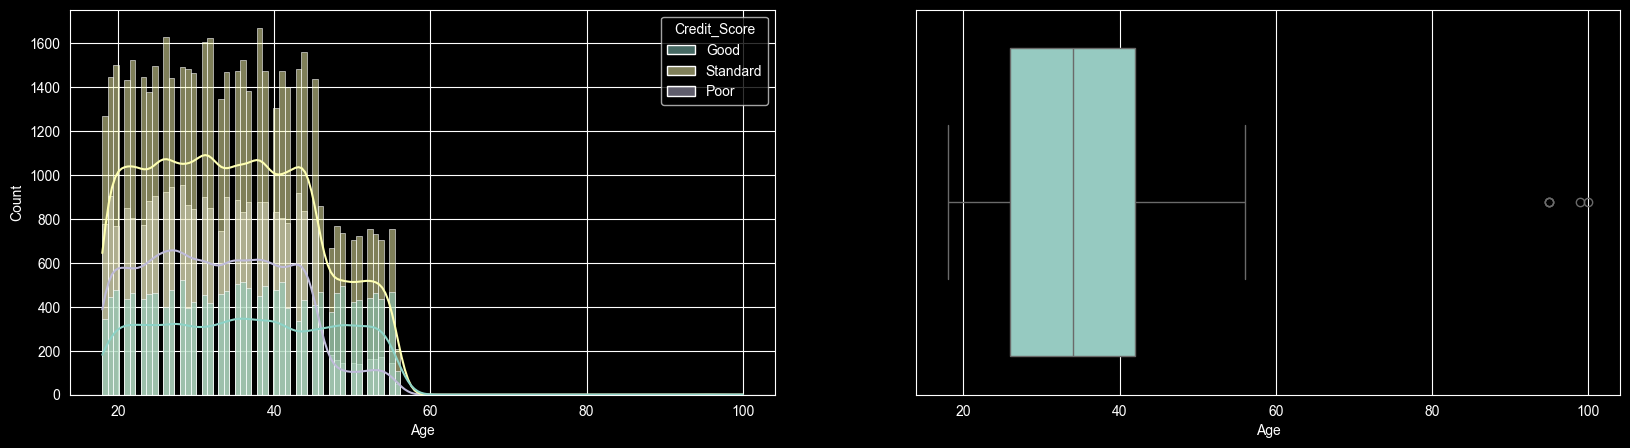

In [373]:
plt.figure(figsize=(20,5))
plt.subplot(121)
sns.histplot(x=df['Age'],hue=df['Credit_Score'],kde=True)
plt.subplot(122)
sns.boxplot(x=df['Age'])

In [374]:
df['Occupation'].value_counts()

Occupation
_______          7062
Lawyer           6575
Architect        6355
Engineer         6350
Scientist        6299
Mechanic         6291
Accountant       6271
Developer        6235
Media_Manager    6232
Teacher          6215
Entrepreneur     6174
Doctor           6087
Journalist       6085
Manager          5973
Musician         5911
Writer           5885
Name: count, dtype: int64

In [375]:
df['Occupation']=df['Occupation'].replace("_______",np.nan,regex=True)

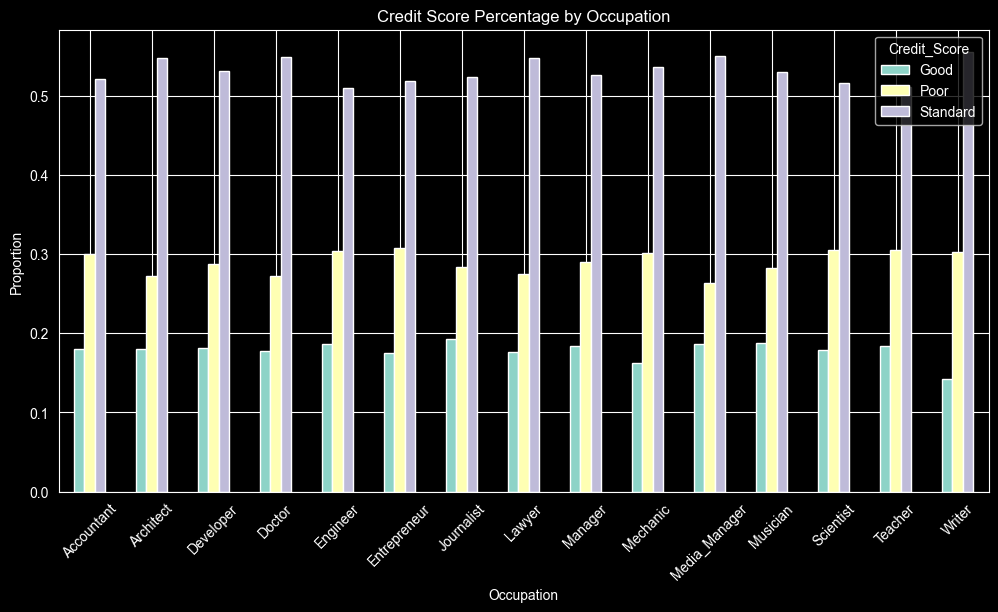

In [376]:
occupation_score = pd.crosstab(
    df["Occupation"],
    df["Credit_Score"],
    normalize="index"
)

occupation_score.plot(kind="bar", figsize=(12,6))
plt.title("Credit Score Percentage by Occupation")
plt.ylabel("Proportion")
plt.xticks(rotation=45)
plt.show()

In [377]:
df['Annual_Income'].unique()[:20]

array(['19114.12', '34847.84', '34847.84_', '143162.64', '30689.89',
       '30689.89_', '35547.71_', '35547.71', '73928.46', '131313.4',
       '10909427.0', '34081.38_', '34081.38', '114838.41', '114838.41_',
       '31370.8', '33751.27', '88640.24', '88640.24_', '54392.16'],
      dtype=object)

In [378]:
df['Annual_Income']=df['Annual_Income'].str.replace("_","",regex=False)
df['Annual_Income']=pd.to_numeric(df['Annual_Income'],errors='coerce')
df["Annual_Income"].describe()

count    1.000000e+05
mean     1.764157e+05
std      1.429618e+06
min      7.005930e+03
25%      1.945750e+04
50%      3.757861e+04
75%      7.279092e+04
max      2.419806e+07
Name: Annual_Income, dtype: float64

<Axes: xlabel='Annual_Income'>

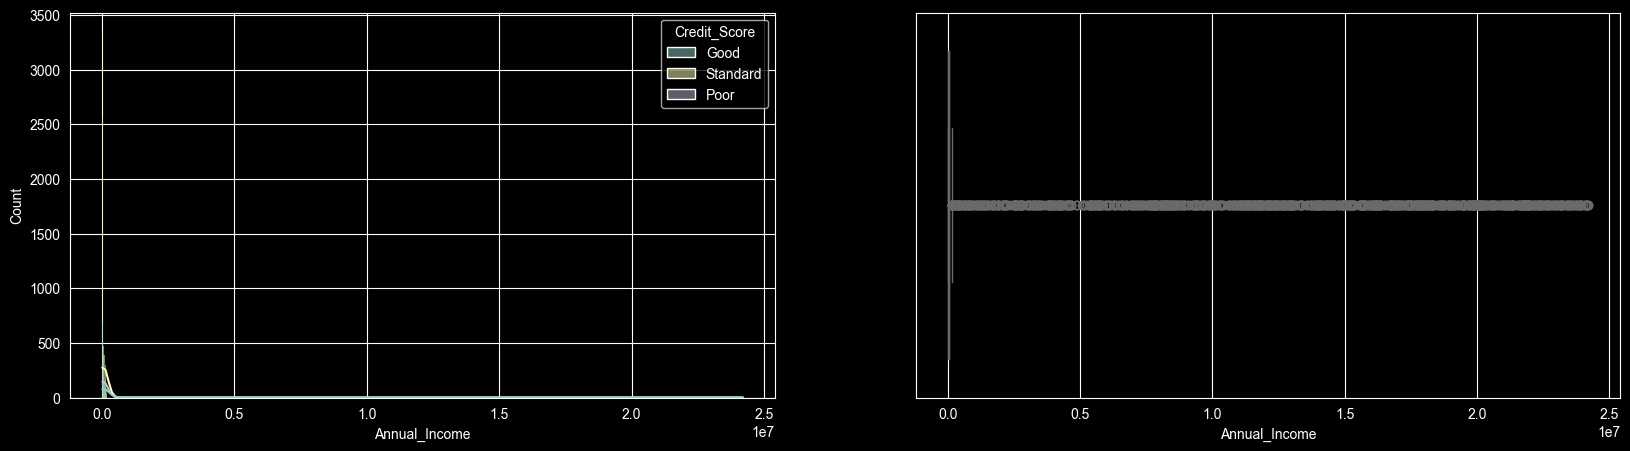

In [379]:
plt.figure(figsize=(20,5))
plt.subplot(121)
sns.histplot(x=df['Annual_Income'],hue=df['Credit_Score'],kde=True)
plt.subplot(122)
sns.boxplot(x=df['Annual_Income'])

In [380]:
df['Num_of_Loan'].unique()

array(['4', '1', '3', '967', '-100', '0', '0_', '2', '3_', '2_', '7', '5',
       '5_', '6', '8', '8_', '9', '9_', '4_', '7_', '1_', '1464', '6_',
       '622', '352', '472', '1017', '945', '146', '563', '341', '444',
       '720', '1485', '49', '737', '1106', '466', '728', '313', '843',
       '597_', '617', '119', '663', '640', '92_', '1019', '501', '1302',
       '39', '716', '848', '931', '1214', '186', '424', '1001', '1110',
       '1152', '457', '1433', '1187', '52', '1480', '1047', '1035',
       '1347_', '33', '193', '699', '329', '1451', '484', '132', '649',
       '995', '545', '684', '1135', '1094', '1204', '654', '58', '348',
       '614', '1363', '323', '1406', '1348', '430', '153', '1461', '905',
       '1312', '1424', '1154', '95', '1353', '1228', '819', '1006', '795',
       '359', '1209', '590', '696', '1185_', '1465', '911', '1181', '70',
       '816', '1369', '143', '1416', '455', '55', '1096', '1474', '420',
       '1131', '904', '89', '1259', '527', '1241', '449', 

In [381]:
df['Num_of_Loan']=df['Num_of_Loan'].str.replace("_","",regex=False)
df['Num_of_Loan']=pd.to_numeric(df['Num_of_Loan'],errors='coerce')
df['Num_of_Loan'].describe()

count    100000.000000
mean          3.009960
std          62.647879
min        -100.000000
25%           1.000000
50%           3.000000
75%           5.000000
max        1496.000000
Name: Num_of_Loan, dtype: float64

In [382]:
(df["Num_of_Loan"] > 20).mean()*100
(df["Num_of_Loan"] < 0).mean()*100

np.float64(3.8760000000000003)

In [383]:
df = df[(df["Num_of_Loan"] >= 0) & (df["Num_of_Loan"] <= 20)]

<Axes: xlabel='Num_of_Loan'>

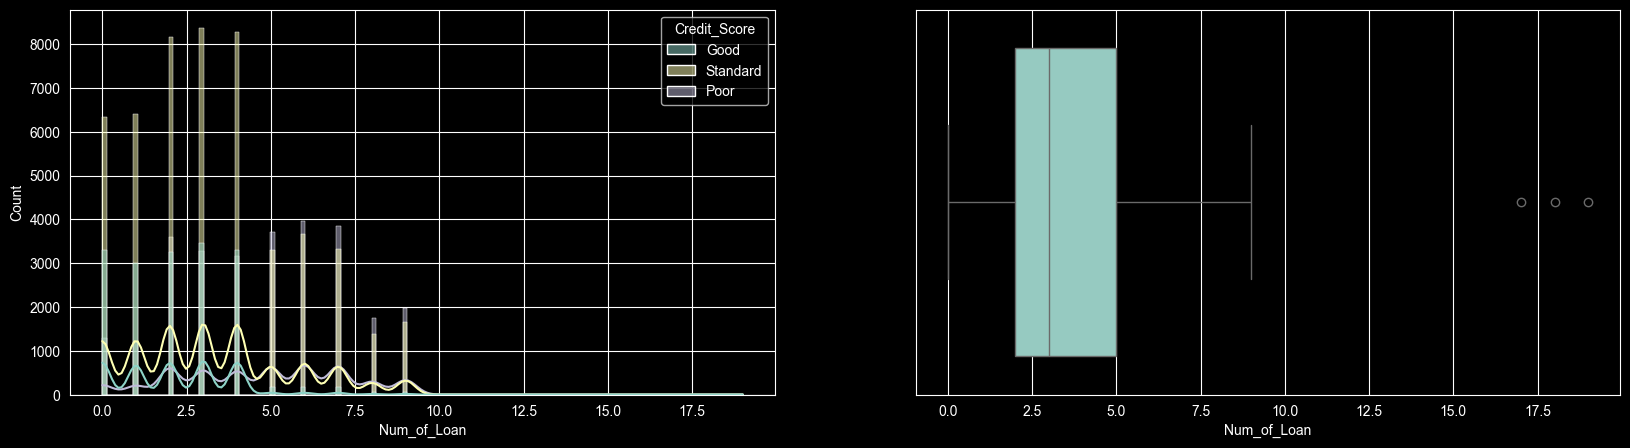

In [384]:
plt.figure(figsize=(20,5))
plt.subplot(121)
sns.histplot(x=df['Num_of_Loan'],hue=df['Credit_Score'],kde=True)
plt.subplot(122)
sns.boxplot(x=df['Num_of_Loan'])

In [385]:
df['Num_of_Delayed_Payment']=df['Num_of_Delayed_Payment'].str.replace("_","",regex=False)
df['Num_of_Delayed_Payment']=pd.to_numeric(df['Num_of_Delayed_Payment'],errors='coerce')
df['Num_of_Delayed_Payment'].describe()


count    88984.000000
mean        31.034399
std        226.813217
min         -3.000000
25%          9.000000
50%         14.000000
75%         18.000000
max       4397.000000
Name: Num_of_Delayed_Payment, dtype: float64

In [386]:
print((df['Num_of_Delayed_Payment']>30).mean()*100)
print((df['Num_of_Delayed_Payment']<0).mean()*100)

0.7401599498196645
0.6387538549997386


In [387]:
df = df[
    (df["Num_of_Delayed_Payment"] >= 0) &
    (df["Num_of_Delayed_Payment"] <= 30)
]

<Axes: xlabel='Num_of_Delayed_Payment'>

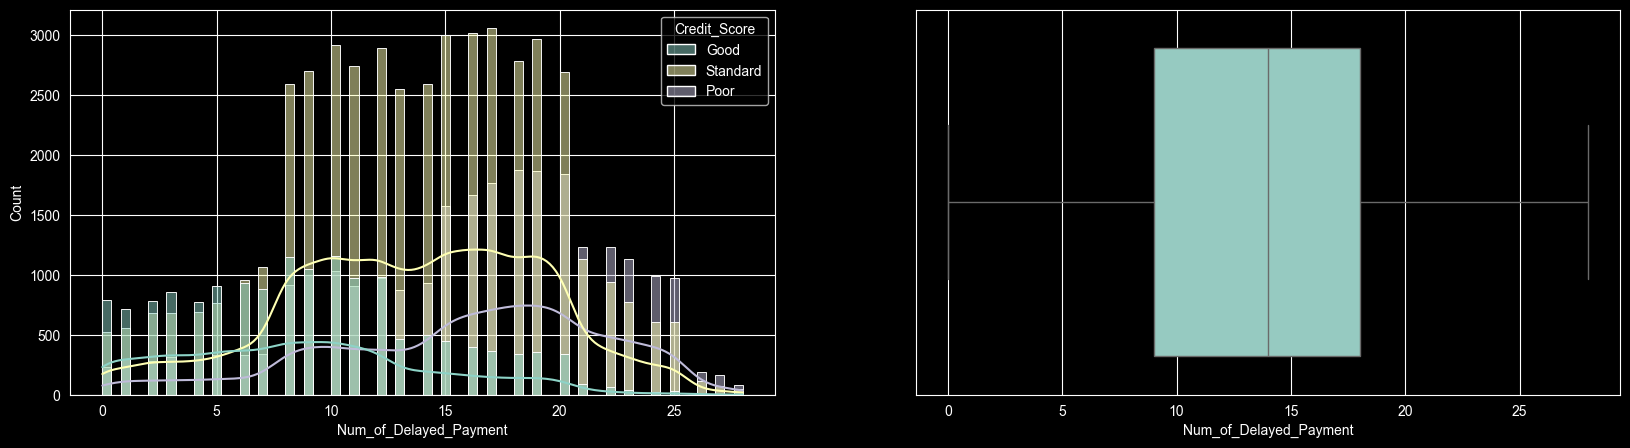

In [388]:
plt.figure(figsize=(20,5))
plt.subplot(121)
sns.histplot(x=df['Num_of_Delayed_Payment'],hue=df['Credit_Score'],kde=True)
plt.subplot(122)
sns.boxplot(x=df['Num_of_Delayed_Payment'])

In [389]:
df['Changed_Credit_Limit']=df['Changed_Credit_Limit'].str.replace("_","",regex=False)
df['Changed_Credit_Limit']=pd.to_numeric(df['Changed_Credit_Limit'],errors='coerce')
df['Changed_Credit_Limit'].describe()

count    85823.000000
mean        10.420557
std          6.796222
min         -6.490000
25%          5.340000
50%          9.440000
75%         14.980000
max         36.490000
Name: Changed_Credit_Limit, dtype: float64

<Axes: xlabel='Changed_Credit_Limit'>

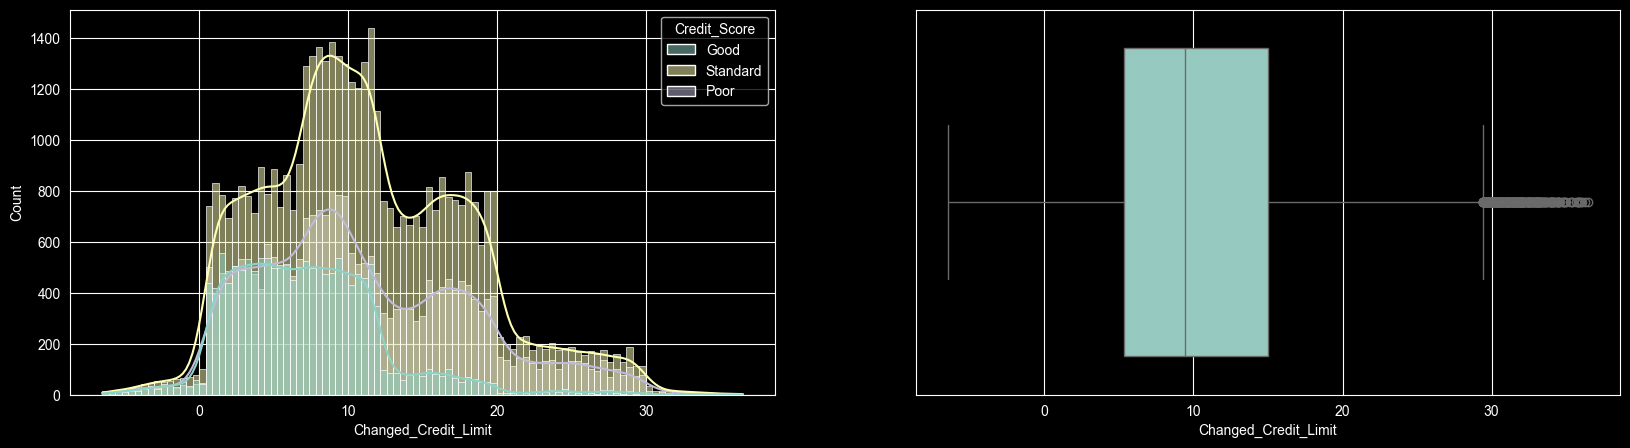

In [390]:
plt.figure(figsize=(20,5))
plt.subplot(121)
sns.histplot(x=df['Changed_Credit_Limit'],hue=df['Credit_Score'],kde=True)
plt.subplot(122)
sns.boxplot(x=df['Changed_Credit_Limit'])

In [391]:
pd.crosstab(df["Credit_Mix"], df["Credit_Score"])

Credit_Score,Good,Poor,Standard
Credit_Mix,,,
Bad,252,10080,6438
Good,10204,3367,7401
Standard,1802,6941,23438
_,3114,5209,9419


In [392]:
df["Credit_Mix"] = df["Credit_Mix"].replace("_", np.nan)

In [393]:
df['Outstanding_Debt']=df['Outstanding_Debt'].str.replace("_","",regex=False)
df['Outstanding_Debt']=pd.to_numeric(df['Outstanding_Debt'],errors='coerce')
df['Outstanding_Debt'].describe()

count    87665.000000
mean      1431.775022
std       1157.403078
min          0.230000
25%        568.590000
50%       1169.760000
75%       1961.870000
max       4998.070000
Name: Outstanding_Debt, dtype: float64

<Axes: xlabel='Outstanding_Debt'>

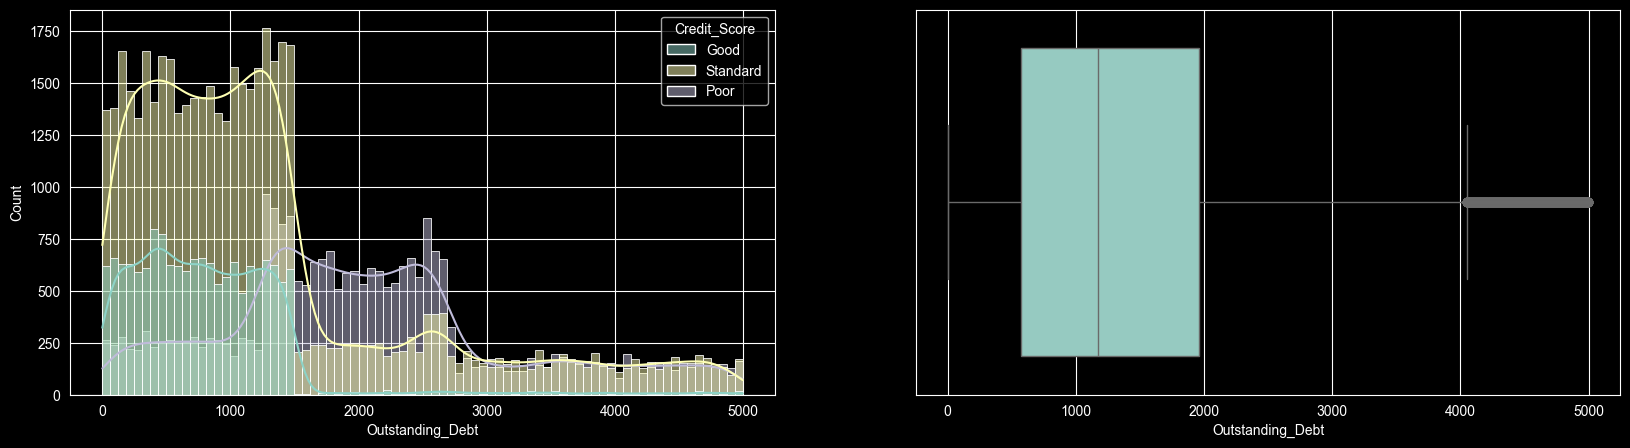

In [394]:
plt.figure(figsize=(20,5))
plt.subplot(121)
sns.histplot(x=df['Outstanding_Debt'],hue=df['Credit_Score'],kde=True)
plt.subplot(122)
sns.boxplot(x=df['Outstanding_Debt'])

In [395]:
def convert(value):
    if pd.isna(value):
        return np.nan
    age=value.split()
    age=[int(x) for x in age if x.isdigit()]
    return sum(age)

In [396]:
df['Credit_History_Age(months)']=df['Credit_History_Age'].apply(convert)

<Axes: xlabel='Credit_History_Age(months)'>

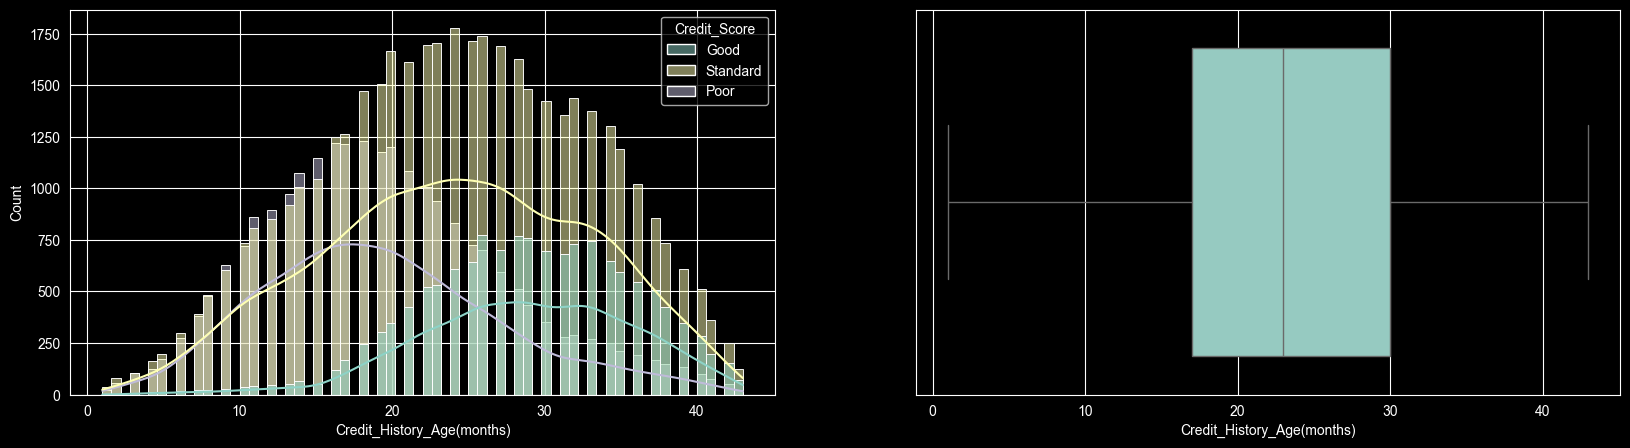

In [397]:
plt.figure(figsize=(20,5))
plt.subplot(121)
sns.histplot(x=df['Credit_History_Age(months)'],hue=df['Credit_Score'],kde=True)
plt.subplot(122)
sns.boxplot(x=df['Credit_History_Age(months)'])

In [398]:
df.drop(columns=['Credit_History_Age'],inplace=True)

In [399]:
df['Amount_invested_monthly']=df['Amount_invested_monthly'].str.replace("_","",regex=False)
df['Amount_invested_monthly']=pd.to_numeric(df['Amount_invested_monthly'],errors='coerce')
df['Amount_invested_monthly'].describe()

count    83742.000000
mean       635.398289
std       2039.491768
min          0.000000
25%         74.368550
50%        135.555880
75%        265.230202
max      10000.000000
Name: Amount_invested_monthly, dtype: float64

<Axes: xlabel='Amount_invested_monthly'>

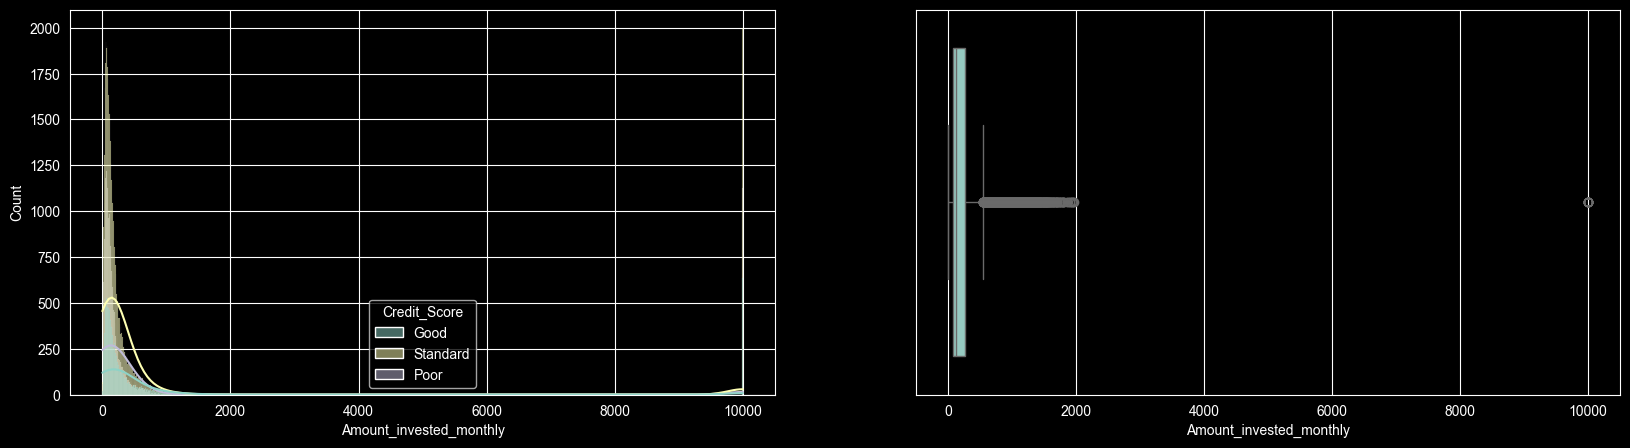

In [400]:
plt.figure(figsize=(20,5))
plt.subplot(121)
sns.histplot(x=df['Amount_invested_monthly'],hue=df['Credit_Score'],kde=True)
plt.subplot(122)
sns.boxplot(x=df['Amount_invested_monthly'])

In [401]:
df["Investment_Ratio"] = (df["Amount_invested_monthly"] * 12) / df["Annual_Income"]
df["Investment_Ratio"].describe()

count    83742.000000
mean         0.240799
std          1.137125
min          0.000000
25%          0.025388
50%          0.046222
75%          0.079528
max         17.086326
Name: Investment_Ratio, dtype: float64

In [402]:
(df["Investment_Ratio"] > 1).mean() * 100

np.float64(3.9468430958763476)

In [403]:
df = df[df["Investment_Ratio"] <= 1]

In [404]:
df['Monthly_Balance']=df['Monthly_Balance'].str.replace("_","",regex=False)
df['Monthly_Balance']=pd.to_numeric(df['Monthly_Balance'],errors='coerce')
df['Monthly_Balance'].describe()

count    7.802700e+04
mean    -3.417620e+22
std      3.375062e+24
min     -3.333333e+26
25%      2.696750e+02
50%      3.362774e+02
75%      4.696361e+02
max      1.602041e+03
Name: Monthly_Balance, dtype: float64

In [405]:
df['Payment_Behaviour'].value_counts()

Payment_Behaviour
Low_spent_Small_value_payments      20559
High_spent_Medium_value_payments    14095
Low_spent_Medium_value_payments     11177
High_spent_Large_value_payments     10985
High_spent_Small_value_payments      9066
Low_spent_Large_value_payments       8353
!@9#%8                               6047
Name: count, dtype: int64

In [406]:
df['Payment_Behaviour']=df['Payment_Behaviour'].replace("!@9#%8",np.nan)

In [407]:
df["Spending_Level"] = df["Payment_Behaviour"].str.split("_").str[0]

df["Payment_Value_Level"] = (
    df["Payment_Behaviour"]
    .str.split("_")
    .str[2]
)

In [408]:
df.drop(columns=['Payment_Behaviour'],inplace=True)

In [409]:
df['Payment_of_Min_Amount']=df['Payment_of_Min_Amount'].replace("NM",np.nan)

In [411]:
df['Type_of_Loan'].value_counts()

Type_of_Loan
Not Specified                                                                                                              1129
Credit-Builder Loan                                                                                                        1020
Personal Loan                                                                                                              1013
Student Loan                                                                                                               1010
Debt Consolidation Loan                                                                                                    1002
                                                                                                                           ... 
Mortgage Loan, Credit-Builder Loan, Home Equity Loan, and Auto Loan                                                           2
Not Specified, Credit-Builder Loan, Credit-Builder Loan, Credit-Builder Loan, Debt Consolid

In [412]:
df["Num_Loan_Types"] = df["Type_of_Loan"].str.count(",") + 1
df["Has_Mortgage"] = df["Type_of_Loan"].str.contains("Mortgage", na=False).astype(int)
df["Has_Student"] = df["Type_of_Loan"].str.contains("Student", na=False).astype(int)
df["Has_Personal"] = df["Type_of_Loan"].str.contains("Personal", na=False).astype(int)
df["Has_Auto"] = df["Type_of_Loan"].str.contains("Auto", na=False).astype(int)
df["Has_Debt_Consolidation"] = df["Type_of_Loan"].str.contains("Debt Consolidation", na=False).astype(int)
df["Has_Credit_Builder"] = df["Type_of_Loan"].str.contains("Credit-Builder", na=False).astype(int)
df.drop(columns=['Type_of_Loan'],inplace=True)

In [413]:
df.head()

,Customer_ID,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,...,Investment_Ratio,Spending_Level,Payment_Value_Level,Num_Loan_Types,Has_Mortgage,Has_Student,Has_Personal,Has_Auto,Has_Debt_Consolidation,Has_Credit_Builder
0,CUS_0xd40,January,23.0,Scientist,19114.12,1824.843333,3,4,3,4,...,0.050485,High,Small,4.0,0,0,1,1,0,1
2,CUS_0xd40,March,NaN,Scientist,19114.12,NaN,3,4,3,4,...,0.051292,Low,Medium,4.0,0,0,1,1,0,1
3,CUS_0xd40,April,23.0,Scientist,19114.12,NaN,3,4,3,4,...,0.125221,Low,Small,4.0,0,0,1,1,0,1
5,CUS_0xd40,June,23.0,Scientist,19114.12,NaN,3,4,3,4,...,0.039194,NaN,NaN,4.0,0,0,1,1,0,1
6,CUS_0xd40,July,23.0,Scientist,19114.12,1824.843333,3,4,3,4,...,0.111966,Low,Small,4.0,0,0,1,1,0,1


In [414]:
month_map = {
    "January":1, "February":2, "March":3,
    "April":4, "May":5, "June":6,
    "July":7, "August":8,
    "September":9, "October":10,
    "November":11, "December":12
}

df["Month"] = df["Month"].map(month_map)

In [415]:
df.head()

,Customer_ID,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,...,Investment_Ratio,Spending_Level,Payment_Value_Level,Num_Loan_Types,Has_Mortgage,Has_Student,Has_Personal,Has_Auto,Has_Debt_Consolidation,Has_Credit_Builder
0,CUS_0xd40,1,23.0,Scientist,19114.12,1824.843333,3,4,3,4,...,0.050485,High,Small,4.0,0,0,1,1,0,1
2,CUS_0xd40,3,NaN,Scientist,19114.12,NaN,3,4,3,4,...,0.051292,Low,Medium,4.0,0,0,1,1,0,1
3,CUS_0xd40,4,23.0,Scientist,19114.12,NaN,3,4,3,4,...,0.125221,Low,Small,4.0,0,0,1,1,0,1
5,CUS_0xd40,6,23.0,Scientist,19114.12,NaN,3,4,3,4,...,0.039194,NaN,NaN,4.0,0,0,1,1,0,1
6,CUS_0xd40,7,23.0,Scientist,19114.12,1824.843333,3,4,3,4,...,0.111966,Low,Small,4.0,0,0,1,1,0,1


In [416]:
df_copy=df.copy()
df_copy.head()

,Customer_ID,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,...,Investment_Ratio,Spending_Level,Payment_Value_Level,Num_Loan_Types,Has_Mortgage,Has_Student,Has_Personal,Has_Auto,Has_Debt_Consolidation,Has_Credit_Builder
0,CUS_0xd40,1,23.0,Scientist,19114.12,1824.843333,3,4,3,4,...,0.050485,High,Small,4.0,0,0,1,1,0,1
2,CUS_0xd40,3,NaN,Scientist,19114.12,NaN,3,4,3,4,...,0.051292,Low,Medium,4.0,0,0,1,1,0,1
3,CUS_0xd40,4,23.0,Scientist,19114.12,NaN,3,4,3,4,...,0.125221,Low,Small,4.0,0,0,1,1,0,1
5,CUS_0xd40,6,23.0,Scientist,19114.12,NaN,3,4,3,4,...,0.039194,NaN,NaN,4.0,0,0,1,1,0,1
6,CUS_0xd40,7,23.0,Scientist,19114.12,1824.843333,3,4,3,4,...,0.111966,Low,Small,4.0,0,0,1,1,0,1


In [417]:
df_copy['Credit_Score']=df_copy['Credit_Score'].map({
'Poor':0,'Standard':1,'Good':2
})
df_copy['Credit_Score'].dtype

dtype('int64')

<Axes: >

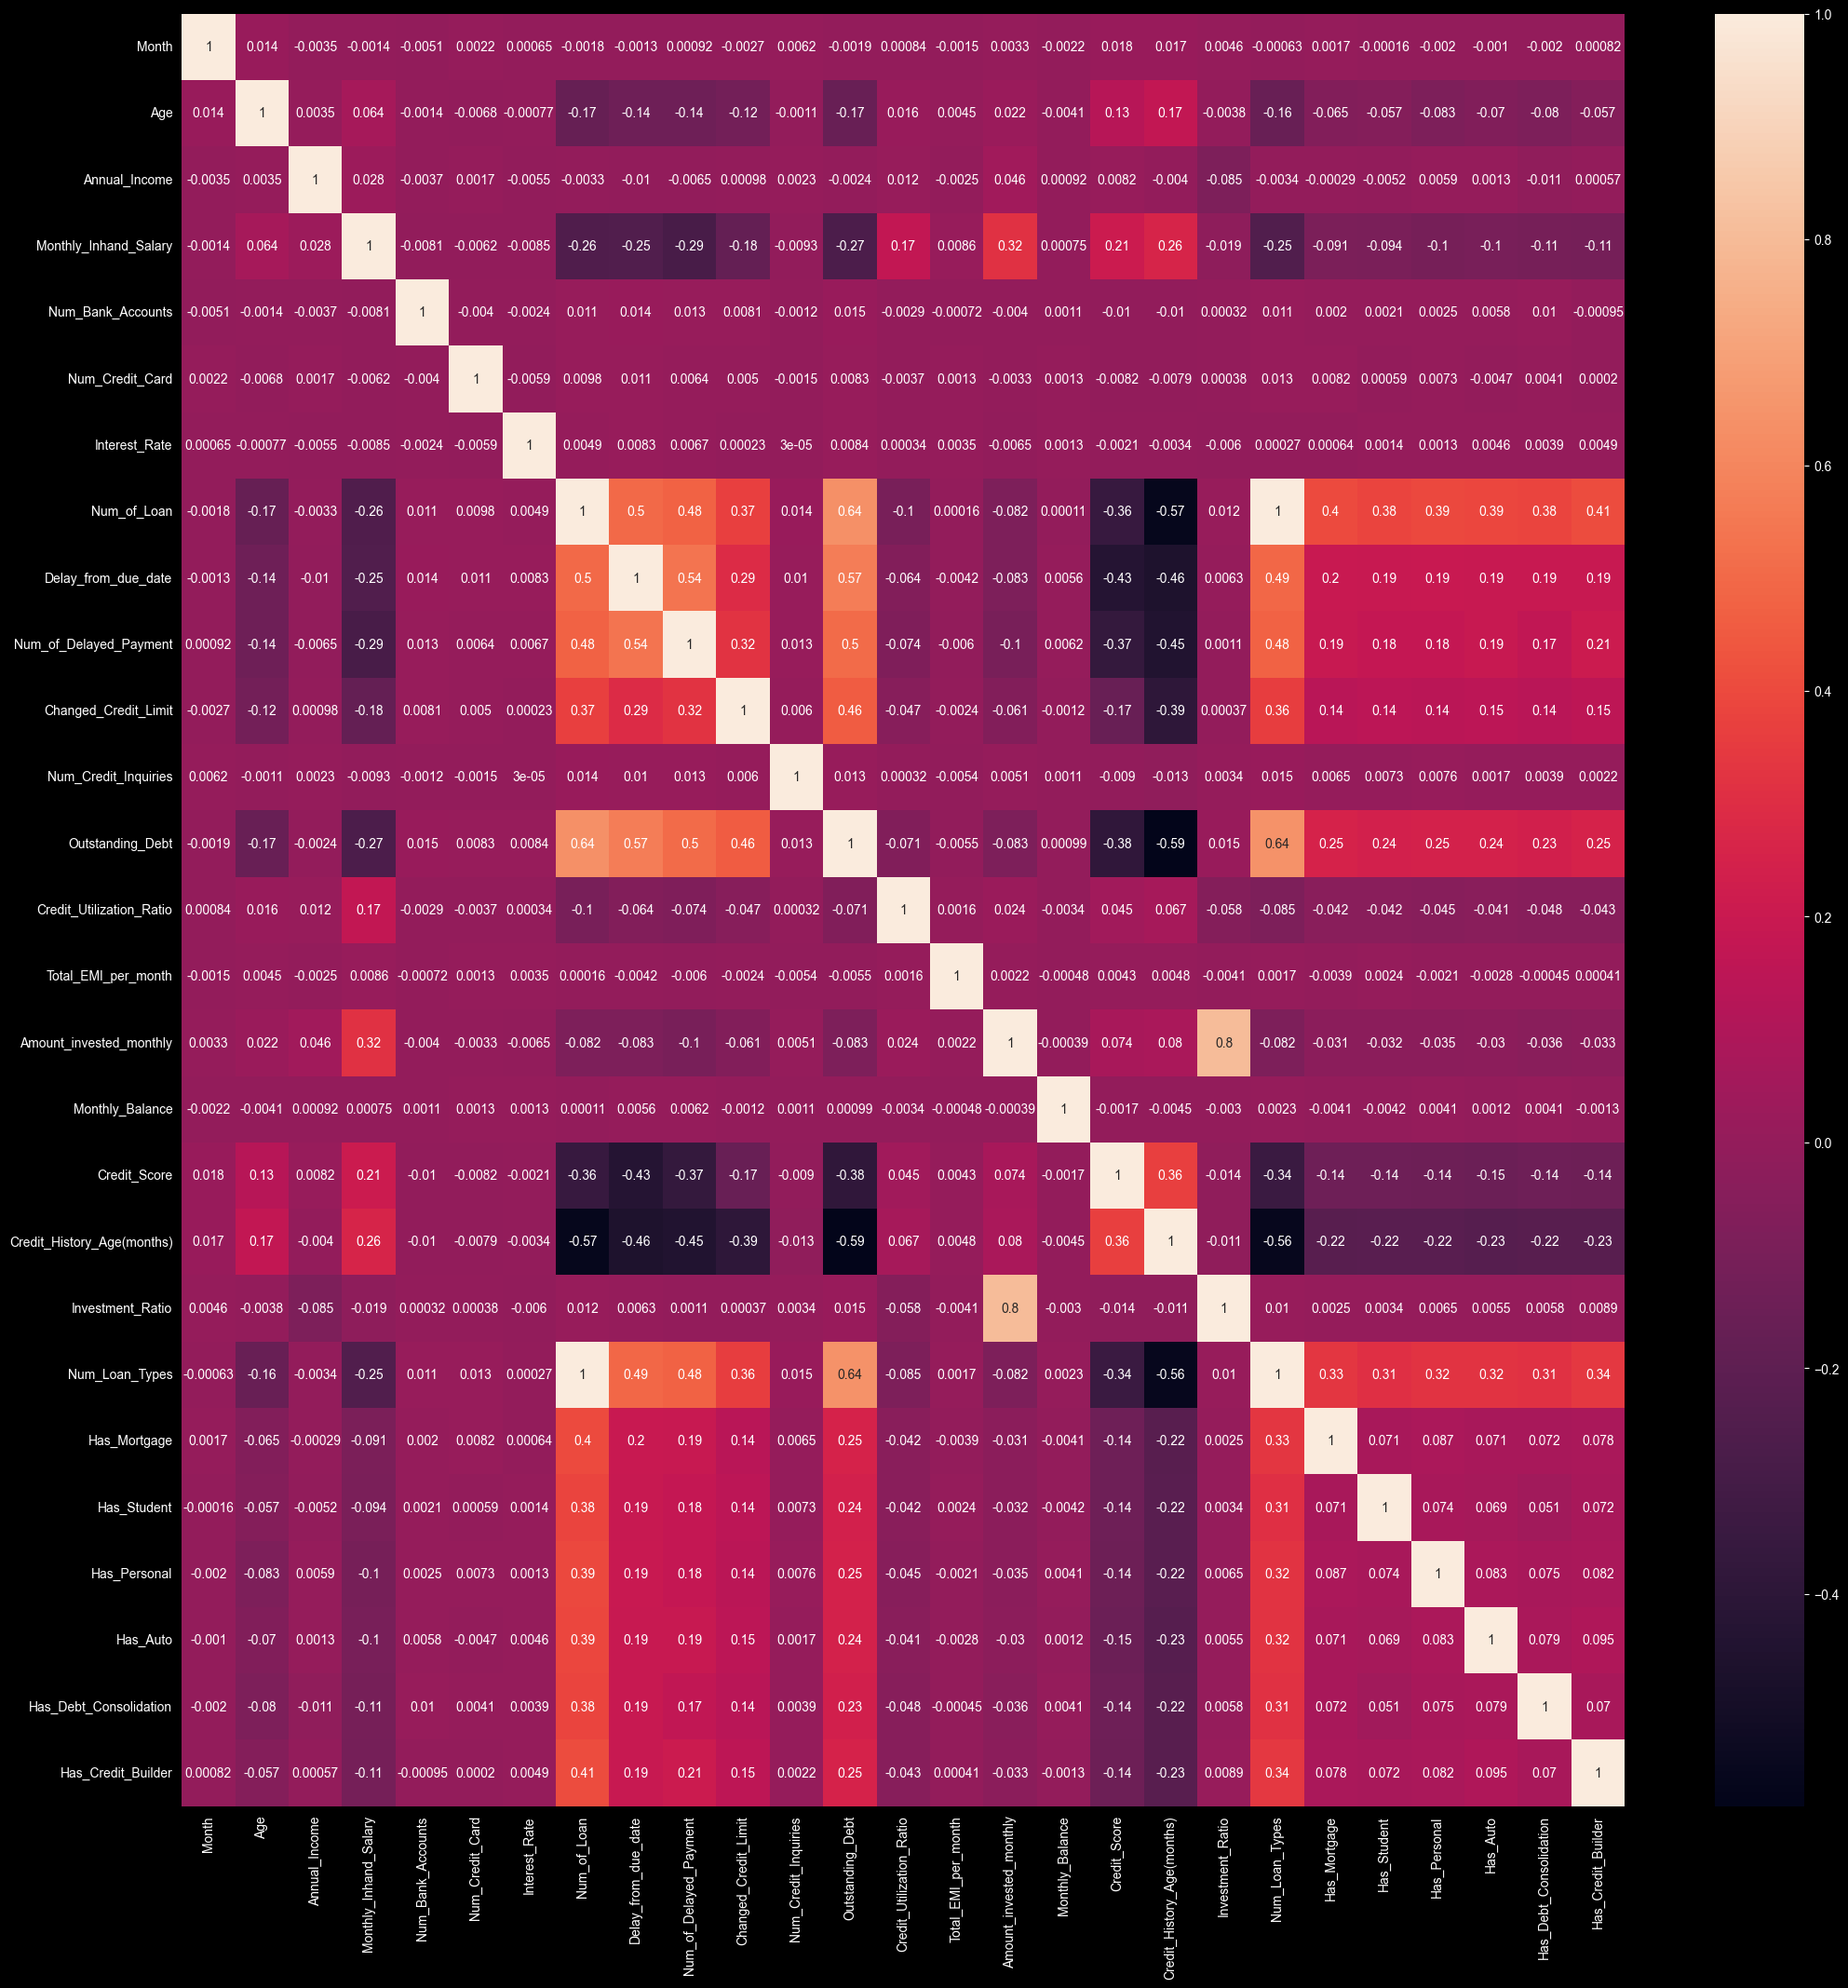

In [418]:
corr=df_copy.corr(numeric_only=True)
plt.figure(figsize=(25,25))
sns.heatmap(corr,annot=True)

In [419]:
cols_to_drop = [
    "Monthly_Inhand_Salary",
    "Num_of_Loan",
    "Type_of_Loan",
    "Payment_Behaviour",
    "Amount_invested_monthly"
]

df.drop(columns=cols_to_drop, inplace=True, errors="ignore")

In [420]:
df.to_csv("cleaned_credit_data.csv", index=False)